# 03 — Inference Demo
## Phân tích APK mới → Dự đoán loại mã độc

**Quy trình inference:**
1. Load model + artifacts từ `processed/`
2. Trích xuất đặc trưng tĩnh từ APK bằng **Androguard** (nhẹ: `APK()` + zipfile DEX)
3. Map token APK → vector 50K chiều (exact + substring + fuzzy matching)
4. Áp dụng `MinMaxScaler` đã fit trên training data
5. Chọn đúng các features đã được Two-Stage Feature Selection chọn
6. Dự đoán → hiển thị kết quả + matched features

> **Yêu cầu:** Đã chạy `02_pipeline.ipynb` để có artifacts trong `processed/`.

## 1. Setup & Load Artifacts

In [1]:
import warnings
warnings.filterwarnings('ignore')

import zipfile
import re
import numpy as np
import pandas as pd
import joblib
import pickle
import json
from pathlib import Path
from difflib import SequenceMatcher

BASE_DIR  = Path(r'H:\tdc_window\Local_Workspace\01_UIT_IT2029_Malware\code\exp-maldroid2020')
OUT_DIR   = BASE_DIR / 'processed'

# Load artifacts
def _load(path):
    if not path.exists():
        raise FileNotFoundError(f'Artifact không tìm thấy: {path}\nHãy chạy 02_pipeline.ipynb trước.')
    return path

model     = joblib.load(_load(OUT_DIR / 'model_best.pkl'))
le        = joblib.load(_load(OUT_DIR / 'label_encoder.pkl'))
scaler    = joblib.load(_load(OUT_DIR / 'scaler.pkl'))

with open(_load(OUT_DIR / 'selected_features.pkl'), 'rb') as f:
    selected_features = pickle.load(f)
with open(_load(OUT_DIR / 'all_feature_names.pkl'), 'rb') as f:
    all_feature_names = pickle.load(f)
with open(_load(OUT_DIR / 'feature_names_after_drop.pkl'), 'rb') as f:
    feature_names_after_drop = pickle.load(f)

with open(OUT_DIR / 'pipeline_summary.json') as f:
    summary = json.load(f)

print('=== Pipeline Summary ===')
print(f'  Best model          : {summary["best_model"]}')
print(f'  Features (total)    : {summary["n_features_total"]:,}')
print(f'  Features (selected) : {summary["n_features_selected"]}')
print(f'  Label classes       : {le.classes_.tolist()}')
m = summary['metrics_best']
print(f'  F1-weighted (CV)    : {m["f1"]:.4f}')
print(f'  MCC (CV)            : {m["mcc"]:.4f}')

=== Pipeline Summary ===
  Best model          : XGBoost
  Features (total)    : 50,621
  Features (selected) : 516
  Label classes       : ['Adware', 'Banking', 'Benign', 'Riskware', 'SMS']
  F1-weighted (CV)    : 0.9996
  MCC (CV)            : 0.9994


## 2. APK Feature Extractor (Androguard — Lightweight)

> **Tối ưu hiệu năng:** Dùng `APK()` (manifest only) + đọc DEX binary qua `zipfile` thay vì `AnalyzeAPK()`.  
> `AnalyzeAPK` build full call-graph (chậm ~10–30 phút/APK); cách này chạy ~5–15 giây/APK.

In [2]:
FUZZY_THRESHOLD = 70  # % similarity tối thiểu để coi là khớp


def _similarity(a: str, b: str) -> float:
    return SequenceMatcher(None, a.lower(), b.lower()).ratio() * 100


def _is_match(feature: str, token: str) -> bool:
    """Exact / substring / fuzzy match."""
    fl, tl = feature.lower(), token.lower()
    if fl == tl:
        return True
    if fl in tl or tl in fl:
        return True
    return _similarity(fl, tl) >= FUZZY_THRESHOLD


def extract_apk_strings(apk_path: str) -> list:
    """
    Trích xuất chuỗi tĩnh từ APK — phiên bản nhẹ, nhanh (~5-15 giây/APK).

    Chiến lược:
      1. Dùng androguard.core.apk.APK (chỉ parse manifest, không build call-graph)
         → permissions, activities, services, receivers, providers, intent filters
      2. Đọc file DEX trực tiếp từ zip bằng regex
         → tên class (Lcom/...; pattern) và method-tag strings
    """
    from androguard.core.apk import APK
    import time as _t
    t0 = _t.time()
    print(f'[APK] Parsing manifest: {Path(apk_path).name}')

    strings = []

    # ── Manifest features (fast: chỉ parse XML) ────────────────────────────
    try:
        a = APK(apk_path)
        for getter in [a.get_permissions, a.get_activities,
                       a.get_services, a.get_receivers, a.get_providers]:
            try:
                result = getter()
                if result:
                    strings.extend(result)
            except Exception:
                pass

        # Intent filter actions & categories
        for comp_type in ('activity', 'service', 'receiver'):
            try:
                ifilters = a.get_intent_filters(comp_type)
                if isinstance(ifilters, dict):
                    for vals in ifilters.values():
                        strings.extend(vals if isinstance(vals, list) else [str(vals)])
            except Exception:
                pass

        # Package name
        try:
            pkg = a.get_package()
            if pkg:
                strings.append(pkg)
        except Exception:
            pass
    except Exception as e:
        print(f'[WARN] APK manifest parse error: {e}')

    n_manifest = len(strings)
    print(f'  Manifest: {n_manifest} strings  ({_t.time()-t0:.1f}s)')

    # ── DEX binary scan (fast: regex trên raw bytes) ────────────────────────
    dex_count = 0
    try:
        with zipfile.ZipFile(apk_path, 'r') as zf:
            dex_files = [n for n in zf.namelist()
                         if re.match(r'^classes\d*\.dex$', n)]
            for dex_name in dex_files:
                raw = zf.read(dex_name)
                # Class references: Lcom/example/Foo; or Landroid/...;
                cls_tokens = re.findall(rb'L[\w$]{1,60}(?:/[\w$]{1,60})+;', raw)
                strings.extend(t.decode('utf-8', errors='ignore')
                                for t in cls_tokens)
                # Method/field strings starting with known Android/Java prefixes
                str_tokens = re.findall(rb'[ -~]{4,80}', raw)
                strings.extend(t.decode('ascii', errors='ignore')
                                for t in str_tokens
                                if t.startswith((b'Landroid', b'Ljava', b'Lcom',
                                                 b'android.', b'java.')))
                dex_count += 1
    except Exception as e:
        print(f'[WARN] DEX scan error: {e}')

    strings = [s.strip() for s in strings if s and s.strip()]
    # Remove duplicates (preserve order)
    seen, uniq = set(), []
    for s in strings:
        if s not in seen:
            seen.add(s)
            uniq.append(s)

    print(f'  DEX ({dex_count} files): {len(uniq) - n_manifest} unique DEX strings')
    print(f'[OK] Total: {len(uniq):,} unique strings  (elapsed: {_t.time()-t0:.1f}s)')
    return uniq


print('extract_apk_strings() defined  — lightweight APK+DEX extractor')

extract_apk_strings() defined  — lightweight APK+DEX extractor


## 3. Build Vector từ APK strings → Inference

In [3]:
def apk_to_vector(apk_strings: list, all_feature_names: list,
                  scaler, feature_names_after_drop: list,
                  selected_features: list) -> tuple:
    """
    Chuyển danh sách chuỗi APK thành vector đã xử lý.

    Trả về:
        vec_final   — numpy array (1, n_selected)
        matched     — dict {feature_name: 1} các features được khớp
        diagnostics — thống kê quá trình matching
    """
    # Bước 1: Tạo dense vector 50K chiều
    feature_set = set(all_feature_names)
    raw_vec = {f: 0.0 for f in feature_names_after_drop}

    matched_exact   = []
    matched_fuzzy   = []
    unmatched_count = 0

    for token in apk_strings:
        found = False
        # Exact match
        if token in raw_vec:
            raw_vec[token] = 1.0
            matched_exact.append(token)
            found = True
        else:
            # Fuzzy match chỉ trên RRFS features (nhanh hơn)
            for feat in selected_features:
                if feat in raw_vec and _is_match(feat, token):
                    raw_vec[feat] = 1.0
                    matched_fuzzy.append((token, feat))
                    found = True
                    break
        if not found:
            unmatched_count += 1

    # Bước 2: Tạo array theo đúng thứ tự feature_names_after_drop
    vec_all = np.array([[raw_vec.get(f, 0.0) for f in feature_names_after_drop]])

    # Bước 3: MinMaxScaler (dùng scaler đã fit trên training data)
    vec_scaled = scaler.transform(vec_all)

    # Bước 4: Chọn đúng RRFS features
    feat_to_idx = {f: i for i, f in enumerate(feature_names_after_drop)}
    sel_indices = [feat_to_idx[f] for f in selected_features if f in feat_to_idx]
    vec_final   = vec_scaled[:, sel_indices]

    matched_features = {f: raw_vec[f] for f in selected_features if raw_vec.get(f, 0) > 0}

    diagnostics = {
        'apk_tokens_total':  len(apk_strings),
        'exact_matches':     len(matched_exact),
        'fuzzy_matches':     len(matched_fuzzy),
        'unmatched_tokens':  unmatched_count,
        'features_activated': len(matched_features),
        'match_ratio_pct':   round(len(matched_features) / len(selected_features) * 100, 1),
    }

    return vec_final, matched_features, diagnostics


print('apk_to_vector() defined.')

apk_to_vector() defined.


In [4]:
def predict_apk(apk_path: str, verbose: bool = True) -> dict:
    """Pipeline đầy đủ: APK → prediction."""
    # Extract strings
    strings = extract_apk_strings(apk_path)

    # Build vector
    vec, matched, diag = apk_to_vector(
        strings, all_feature_names, scaler,
        feature_names_after_drop, selected_features
    )

    # Predict
    pred_enc = int(model.predict(vec)[0])
    pred_label = le.classes_[pred_enc] if pred_enc < len(le.classes_) else str(pred_enc)

    # Probability
    proba = None
    try:
        proba = model.predict_proba(vec)[0]
    except Exception:
        pass

    result = {
        'file':          Path(apk_path).name,
        'prediction':    pred_label,
        'encoded_label': pred_enc,
        'probabilities': {le.classes_[i]: round(float(p), 4) for i, p in enumerate(proba)} if proba is not None else None,
        'confidence':    round(float(max(proba)) * 100, 1) if proba is not None else None,
        'matched_features': matched,
        'diagnostics':   diag,
    }

    if verbose:
        print(f'\n{"═"*50}')
        print(f'  APK          : {result["file"]}')
        print(f'  Prediction   : {result["prediction"]}')
        if result['confidence']:
            print(f'  Confidence   : {result["confidence"]}%')
        print(f'  {"─"*46}')
        print(f'  APK tokens   : {diag["apk_tokens_total"]:,}')
        print(f'  Exact match  : {diag["exact_matches"]}')
        print(f'  Fuzzy match  : {diag["fuzzy_matches"]}')
        print(f'  Unmatched    : {diag["unmatched_tokens"]:,}')
        print(f'  Features hit : {diag["features_activated"]} / {len(selected_features)} ({diag["match_ratio_pct"]}%)')
        if result['probabilities']:
            print(f'  {"─"*46}')
            print('  Class probabilities:')
            for cls, prob in sorted(result['probabilities'].items(), key=lambda x: -x[1]):
                bar = '█' * int(prob * 30)
                print(f'    {str(cls):<15} {bar:<30} {prob:.4f}')
        if matched:
            print(f'  {"─"*46}')
            print(f'  Top matched features (max 10):')
            for f in list(matched.keys())[:10]:
                print(f'    ✓ {f[:60]}')
        print(f'{"═"*50}')

    return result


print('predict_apk() defined.')

predict_apk() defined.


## 4. Chạy dự đoán

Thay `APK_PATH` bằng đường dẫn thực tế đến file APK bạn muốn phân tích.

In [5]:
# ── Chỉnh đường dẫn APK tại đây ──────────────────────────────────────────────
APK_PATH = r'H:\tdc_window\Local_Workspace\01_UIT_IT2029_Malware\code\Android-Malware-Detection-Drebinv1-CICMalDroid2020\InsecureBankv2.apk'
# ─────────────────────────────────────────────────────────────────────────────

from pathlib import Path as _P
if _P(APK_PATH).exists():
    result = predict_apk(APK_PATH)
else:
    print(f'[WARN] APK không tìm thấy: {APK_PATH}')
    print('Hãy thay APK_PATH bằng đường dẫn thực tế.')
    print('\nCó thể test với APK mẫu từ:')
    print('  - https://github.com/dineshshetty/Android-InsecureBankv2')
    print('  - Bất kỳ file .apk nào bạn muốn phân tích')

[APK] Parsing manifest: InsecureBankv2.apk


2026-03-23 19:38:46.436 | INFO     | androguard.core.apk:_apk_analysis:410 - Starting analysis on AndroidManifest.xml
2026-03-23 19:38:46.437 | DEBUG    | androguard.core.axml:__init__:1129 - AXMLPrinter
2026-03-23 19:38:46.438 | DEBUG    | androguard.core.axml:__init__:449 - AXMLParser
2026-03-23 19:38:46.440 | DEBUG    | androguard.core.axml:__init__:482 - FIRST HEADER <ARSCHeader idx='0x00000000' type='3' header_size='8' size='7588'>
2026-03-23 19:38:46.441 | DEBUG    | androguard.core.axml:__init__:540 - STRING_POOL <ARSCHeader idx='0x00000008' type='1' header_size='28' size='3812'>
2026-03-23 19:38:46.442 | DEBUG    | androguard.core.axml:is_valid:575 - True
2026-03-23 19:38:46.442 | DEBUG    | androguard.core.axml:_do_next:593 - M_EVENT -1
2026-03-23 19:38:46.443 | DEBUG    | androguard.core.axml:_do_next:609 - NEXT HEADER <ARSCHeader idx='0x00000eec' type='384' header_size='8' size='80'>
2026-03-23 19:38:46.444 | DEBUG    | androguard.core.axml:_do_next:618 - AXML contains a RES

  Manifest: 26 strings  (0.8s)
  DEX (1 files): 7418 unique DEX strings
[OK] Total: 7,444 unique strings  (elapsed: 0.9s)

══════════════════════════════════════════════════
  APK          : InsecureBankv2.apk
  Prediction   : Adware
  Confidence   : 98.6%
  ──────────────────────────────────────────────
  APK tokens   : 7,444
  Exact match  : 21
  Fuzzy match  : 7268
  Unmatched    : 155
  Features hit : 30 / 516 (5.8%)
  ──────────────────────────────────────────────
  Class probabilities:
    Adware          █████████████████████████████  0.9863
    SMS                                            0.0074
    Banking                                        0.0058
    Benign                                         0.0004
    Riskware                                       0.0002
  ──────────────────────────────────────────────
  Top matched features (max 10):
    ✓ 'android.intent.action.BATTERY_CHANGED'
    ✓ 'android.intent.action.EDIT'
    ✓ 'android.intent.extra.REFERRER_NAME'
    ✓ a

## 5. Batch inference — nhiều APK

In [6]:
# ── Phân tích một thư mục APK ─────────────────────────────────────────────────
APK_FOLDER = r'C:\path\to\your\apk\folder'   # ← Thay đường dẫn
# ─────────────────────────────────────────────────────────────────────────────

apk_dir = Path(APK_FOLDER)
if apk_dir.exists():
    apk_files = list(apk_dir.glob('*.apk'))
    print(f'Tìm thấy {len(apk_files)} file APK')

    batch_results = []
    for apk in apk_files:
        try:
            r = predict_apk(str(apk), verbose=False)
            batch_results.append({
                'file':       r['file'],
                'prediction': r['prediction'],
                'confidence': r['confidence'],
                'match_ratio': r['diagnostics']['match_ratio_pct'],
            })
            print(f'  {r["file"]:<40} → {r["prediction"]:<15} ({r["confidence"]}%)')
        except Exception as e:
            print(f'  [ERROR] {apk.name}: {e}')

    if batch_results:
        df_batch = pd.DataFrame(batch_results)
        print(f'\n=== Batch Prediction Summary ===')
        print(df_batch['prediction'].value_counts().to_string())
        df_batch.to_csv(BASE_DIR / 'processed' / 'batch_predictions.csv', index=False)
        print(f'\nSaved: batch_predictions.csv')
else:
    print(f'Thư mục APK không tồn tại: {APK_FOLDER}')
    print('Cell này dành cho batch inference — bỏ qua nếu chỉ cần single APK.')

Thư mục APK không tồn tại: C:\path\to\your\apk\folder
Cell này dành cho batch inference — bỏ qua nếu chỉ cần single APK.


## 6. Giải thích quyết định — Top features đóng góp

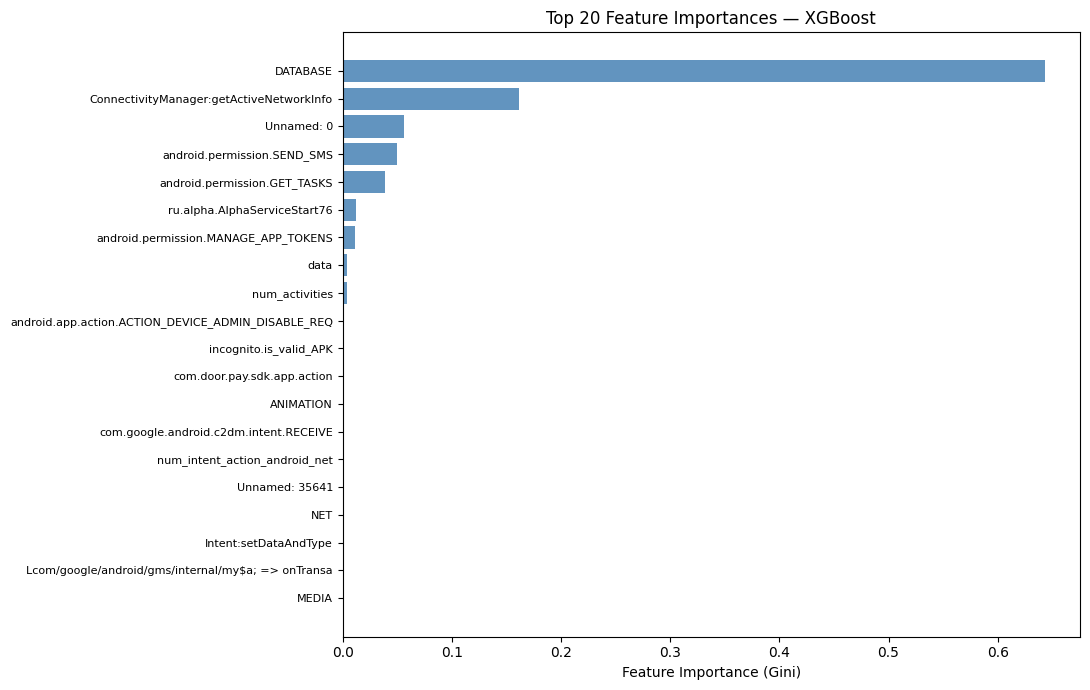

In [7]:
# Nếu model là Random Forest → dùng feature_importances_ để giải thích
try:
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=selected_features)\
                 .sort_values(ascending=False)

    top20 = feat_imp.head(20)
    short = [f[:50] for f in top20.index]

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(range(20), top20.values[::-1], color='steelblue', alpha=0.85)
    ax.set_yticks(range(20))
    ax.set_yticklabels(short[::-1], fontsize=8)
    ax.set_xlabel('Feature Importance (Gini)')
    ax.set_title(f'Top 20 Feature Importances — {summary["best_model"]}')
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'notebooks' / 'figures' / '10_feature_importance.png',
                dpi=150, bbox_inches='tight')
    plt.show()
except AttributeError:
    print(f'Model {summary["best_model"]} không có feature_importances_.')
    print('Feature importance chỉ khả dụng với RandomForest / XGBoost.')

## 7. Tóm tắt toàn bộ quy trình

In [8]:
print('═' * 60)
print('  Quy trình thực nghiệm — CIC-MalDroid 2020 Static Analysis')
print('═' * 60)
print()
print('  [01_eda.ipynb]         EDA')
print(f'    ├── {summary["n_samples"]:,} APK samples, {summary["n_features_total"]:,} static features')
print(f'    └── {len(le.classes_)} lớp: {le.classes_.tolist()}')
print()
print('  [02_pipeline.ipynb]    Feature Reduction + Training')
print(f'    ├── Two-Stage: {summary["n_features_total"]:,} → {summary["n_features_selected"]:,} features')
print(f'    ├──   Stage 1: Chi-square SelectKBest  (top 2000)')
print(f'    ├──   Stage 2: Correlation filter ρ > 0.95')
print(f'    ├── Best: {summary["best_model"]}')
print(f'    ├── F1   : {summary["metrics_best"]["f1"]:.4f}')
print(f'    ├── MCC  : {summary["metrics_best"]["mcc"]:.4f}')
print(f'    └── AUC  : {summary["metrics_best"].get("roc_auc", "N/A")}')
print()
print('  [03_inference.ipynb]   APK Inference')
print('    ├── APK() + zipfile DEX scan → lightweight, ~5-15s/APK')
print('    ├── fuzzy match → vector → scaler → Two-Stage features')
print('    └── Predict: Adware / Banking / SMS / Riskware / Benign')
print()
print('═' * 60)

════════════════════════════════════════════════════════════
  Quy trình thực nghiệm — CIC-MalDroid 2020 Static Analysis
════════════════════════════════════════════════════════════

  [01_eda.ipynb]         EDA
    ├── 11,598 APK samples, 50,621 static features
    └── 5 lớp: ['Adware', 'Banking', 'Benign', 'Riskware', 'SMS']

  [02_pipeline.ipynb]    Feature Reduction + Training
    ├── Two-Stage: 50,621 → 516 features
    ├──   Stage 1: Chi-square SelectKBest  (top 2000)
    ├──   Stage 2: Correlation filter ρ > 0.95
    ├── Best: XGBoost
    ├── F1   : 0.9996
    ├── MCC  : 0.9994
    └── AUC  : 0.9999996136286254

  [03_inference.ipynb]   APK Inference
    ├── APK() + zipfile DEX scan → lightweight, ~5-15s/APK
    ├── fuzzy match → vector → scaler → Two-Stage features
    └── Predict: Adware / Banking / SMS / Riskware / Benign

════════════════════════════════════════════════════════════
